# Mortgage Default Risk Modeling

## Business Problem
This project builds a Probability of Default (PD) model using mortgage loan data. The objective is to estimate the likelihood that a borrower becomes seriously delinquent (90+ days past due) based on origination characteristics.

Such models are commonly used by lenders to:

- Assess borrower credit risk

- Support underwriting decisions

- Monitor portfolio risk

- Inform risk-based pricing.

## Data Source
The dataset comes from the Fannie Mae Single-Family Loan Performance dataset, which contains loan origination and monthly performance information for mortgages purchased or guaranteed by Fannie Mae.

Two types of information exist in the dataset:

- Origination data: borrower and loan characteristics

- Performance data: monthly loan status, including delinquency information.

For this project, a sample of 1 million records was used to simulate a manageable portfolio for modeling.

# Data Engineering(SQL+ DuckDB)
Because the raw dataset contains monthly loan performance records, the data must be transformed to obtain one row per loan for modeling.

DuckDB SQL was used to:

- Extract relevant columns

- Identify delinquency status

- Create a loan-level dataset

- Combine origination and performance variables.

This approach reflects how risk teams typically prepare modeling datasets from transactional loan data.

In [1]:
# Creating a persistent DuckDB database
import duckdb, os

db_path = r"C:\Projects\fannie_risk\risk.db"
con = duckdb.connect(db_path)

con.execute("SELECT 1").fetchall(), db_path

([(1,)], 'C:\\Projects\\fannie_risk\\risk.db')

In [4]:
# Building a 1000000 row sample table
path = r"C:\Users\ADMIN\Desktop\DATA SCIENCE Resources\2022Q1.csv"

con.execute("DROP TABLE IF EXISTS performance_sample")

con.execute("""
CREATE TABLE performance_sample AS
SELECT *
FROM read_csv_auto(?, delim='|', header=false)
LIMIT 1000000
""", [path])

In [5]:
# Sample verification
con.execute("SELECT COUNT(*) FROM performance_sample").fetchall()

[(1000000,)]

In [6]:
# Inspecting table structure
con.execute("""
PRAGMA table_info('performance_sample')
""").fetchdf()

,cid,name,type,notnull,dflt_value,pk
0,0,column000,VARCHAR,False,None,False
1,1,column001,VARCHAR,False,None,False
2,2,column002,VARCHAR,False,None,False
3,3,column003,VARCHAR,False,None,False
4,4,column004,VARCHAR,False,None,False
...,...,...,...,...,...,...
105,105,column105,VARCHAR,False,None,False
106,106,column106,BIGINT,False,None,False
107,107,column107,DOUBLE,False,None,False
108,108,column108,BIGINT,False,None,False


In [7]:
# Inspecting the first 5 rows
con.execute("""
SELECT *
FROM performance_sample
LIMIT 5
""").fetchdf()

,column000,column001,column002,column003,column004,column005,column006,column007,column008,column009,...,column100,column101,column102,column103,column104,column105,column106,column107,column108,column109
0,None,000130357804,012022,R,Other,"Lakeview Loan Servicing, LLC",None,3.375,3.375,255000.0,...,None,7,N,None,None,7,<NA>,NaN,7,None
1,None,000130357804,022022,R,Other,"Lakeview Loan Servicing, LLC",None,3.375,3.375,255000.0,...,None,7,N,None,None,7,<NA>,NaN,7,None
2,None,000130357804,032022,R,Other,"Lakeview Loan Servicing, LLC",None,3.375,3.375,255000.0,...,None,7,N,None,None,7,<NA>,NaN,7,None
3,None,000130357804,042022,R,Other,"Lakeview Loan Servicing, LLC",None,3.375,3.375,255000.0,...,None,7,N,None,None,7,<NA>,NaN,7,None
4,None,000130357804,052022,R,Other,"Lakeview Loan Servicing, LLC",None,3.375,3.375,255000.0,...,None,7,N,None,None,7,<NA>,NaN,7,None


In [2]:
# Creating a new sample csv to delete the large fannie mae csv
con.execute("""
COPY performance_sample
TO 'loan_sample_1M.csv'
WITH (HEADER, DELIMITER ',')
""")

In [8]:
# Confirming deliquency column
con.execute("""
SELECT column039, COUNT(*)
FROM performance_sample
GROUP BY column039
ORDER BY COUNT(*) DESC
LIMIT 10
""").fetchall()

[('00', 986541),
 ('01', 7699),
 ('02', 1857),
 ('03', 903),
 ('04', 629),
 ('05', 555),
 ('06', 375),
 ('07', 274),
 ('08', 240),
 ('09', 185)]

In [9]:
# Creating a loan performance table using dynamic variables and loan ID
con.execute("DROP TABLE IF EXISTS performance")

con.execute("""
CREATE TABLE performance AS
SELECT
    column001 AS loan_id,
    column002 AS reporting_period,
    column039 AS delinquency_status,
    column011 AS current_actual_upb,
    column043 AS zero_balance_code
FROM performance_sample
""")

In [10]:
con.execute("SELECT * FROM performance LIMIT 10").fetchdf()

,loan_id,reporting_period,delinquency_status,current_actual_upb,zero_balance_code
0,000130357804,012022,00,255000.00,None
1,000130357804,022022,00,255000.00,None
2,000130357804,032022,00,255000.00,None
3,000130357804,042022,00,254000.00,None
4,000130357804,052022,00,254000.00,None
5,000130357804,062022,00,253000.00,None
6,000130357804,072022,00,253000.00,None
7,000130357804,082022,00,253000.00,None
8,000130357804,092022,00,252104.53,None
9,000130357804,102022,00,251686.22,None


In [11]:
# Creating loan acquisition table using loan origination characteristics
con.execute("DROP TABLE IF EXISTS acquisition")

con.execute("""
CREATE TABLE acquisition AS
SELECT DISTINCT
    column001 AS loan_id,
    column009 AS original_upb,
    column007 AS original_interest_rate,
    column012 AS original_loan_term,
    column019 AS original_ltv,
    column022 AS dti,
    column023 AS credit_score,
    column026 AS loan_purpose,
    column029 AS occupancy_status,
    column027 AS property_type,
    column021 AS number_of_borrowers
FROM performance_sample
""")

In [12]:
con.execute("SELECT COUNT(*) FROM acquisition").fetchall()

[(23721,)]

In [13]:
con.execute("SELECT * FROM acquisition LIMIT 5").fetchdf()

,loan_id,original_upb,original_interest_rate,original_loan_term,original_ltv,dti,credit_score,loan_purpose,occupancy_status,property_type,number_of_borrowers
0,000130360709,149000.0,3.500,360,95,25,730,P,P,SF,1
1,000130360711,440000.0,3.875,360,68,37,699,C,P,SF,1
2,000130360715,92000.0,4.250,360,53,45,796,R,I,PU,1
3,000130360717,178000.0,2.875,360,59,41,689,R,P,SF,1
4,000130360722,219000.0,3.375,360,63,34,806,C,P,SF,1


# Default Definition
In credit risk modeling, default must be clearly defined.

For this analysis, a loan is considered defaulted if it ever reaches **90 or more days delinquent (DPD)**.

This is a common definition used in mortgage risk modeling.

A binary target variable was created:

- 1 = loan ever reached 90+ DPD

- 0 = loan did not reach 90+ DPD

This variable serves as the dependent variable for the PD model.

In [14]:
# Creating a default table
con.execute("DROP TABLE IF EXISTS default_flag")

con.execute("""
CREATE TABLE default_flag AS
SELECT
    loan_id,
    MAX(CASE 
            WHEN delinquency_status >= '03' 
            THEN 1 
            ELSE 0 
        END) AS ever_90_plus
FROM performance
GROUP BY loan_id
""")

In [15]:
# Checking default rate
con.execute("""
SELECT 
    AVG(ever_90_plus) AS default_rate
FROM default_flag
""").fetchall()

[(0.022391836046217424,)]

In [16]:
# Merging acquisition table and default flag to create modeling table
con.execute("DROP TABLE IF EXISTS modeling_data")

con.execute("""
CREATE TABLE modeling_data AS
SELECT 
    a.*,
    d.ever_90_plus
FROM acquisition a
LEFT JOIN default_flag d
ON a.loan_id = d.loan_id
""")

In [17]:
con.execute("SELECT COUNT(*) FROM modeling_data").fetchall()

[(23721,)]

In [18]:
con.execute("SELECT * FROM modeling_data LIMIT 5").fetchdf()

,loan_id,original_upb,original_interest_rate,original_loan_term,original_ltv,dti,credit_score,loan_purpose,occupancy_status,property_type,number_of_borrowers,ever_90_plus
0,000130360709,149000.0,3.500,360,95,25,730,P,P,SF,1,0
1,000130360711,440000.0,3.875,360,68,37,699,C,P,SF,1,0
2,000130360715,92000.0,4.250,360,53,45,796,R,I,PU,1,0
3,000130360717,178000.0,2.875,360,59,41,689,R,P,SF,1,0
4,000130360722,219000.0,3.375,360,63,34,806,C,P,SF,1,1


In [2]:
# Checking tables created in duckDB
con.execute("SHOW TABLES").fetchall()

[('acquisition',),
 ('default_flag',),
 ('modeling_data',),
 ('performance',),
 ('performance_sample',)]

In [2]:
# Loading modeling data into Pandas
import pandas as pd

df = con.execute("SELECT * FROM modeling_data").fetchdf()
df.shape, df["ever_90_plus"].mean()

((23721, 12), np.float64(0.022385228278740357))

# Feature Selection
The model uses borrower and loan characteristics typically used in mortgage underwriting.

Key variables include:

- credit score

- loan-to-value ratio (LTV)

- debt-to-income ratio (DTI)

- loan term

- interest rate

- property type

- number of borrowers

- occupancy status.

These variables are known drivers of mortgage default risk.

In [3]:
# Data cleaning and feature preparation
# Select features (X) and target (y)
y = df["ever_90_plus"].astype(int)

X = df[[
    "original_upb",
    "original_interest_rate",
    "original_loan_term",
    "original_ltv",
    "dti",
    "credit_score",
    "loan_purpose",
    "occupancy_status",
    "property_type",
    "number_of_borrowers"
]].copy()

X.isna().mean().sort_values(ascending=False).head(15)

credit_score              0.000759
dti                       0.000126
original_interest_rate    0.000000
original_upb              0.000000
original_ltv              0.000000
original_loan_term        0.000000
loan_purpose              0.000000
occupancy_status          0.000000
property_type             0.000000
number_of_borrowers       0.000000
dtype: float64

# Data Preparation
Before modeling, the dataset was prepared by:

- Handling missing values

- Encoding categorical variables

- Splitting the dataset into training and test sets.

In [4]:
# Filling missing values in credit score and dti
X["credit_score"] = X["credit_score"].fillna(X["credit_score"].median())
X["dti"] = X["dti"].fillna(X["dti"].median())

In [5]:
X.isna().sum()

original_upb              0
original_interest_rate    0
original_loan_term        0
original_ltv              0
dti                       0
credit_score              0
loan_purpose              0
occupancy_status          0
property_type             0
number_of_borrowers       0
dtype: int64

In [6]:
# One-hot encoding categorical variables
X_encoded = pd.get_dummies(
    X,
    columns=["loan_purpose", "occupancy_status", "property_type"],
    drop_first=True
)

X_encoded.shape

(23721, 15)

In [7]:
# Splitting train and test data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape, y_train.mean(), y_test.mean()

((16604, 15),
 (7117, 15),
 np.float64(0.022404239942182606),
 np.float64(0.02234087396374877))

# PD Model (Logistic Regression)
A logistic regression model was used to estimate the probability of default.

Logistic regression is widely used in credit risk modeling because:

- It produces interpretable coefficients

- It estimates probabilities directly

- It is widely accepted in regulatory environments.

In [8]:
# Fitting alogistic regression model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [9]:
# Evaluating model ROC-AUC
from sklearn.metrics import roc_auc_score

# Predict probabilities
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Compute AUC
auc = roc_auc_score(y_test, y_pred_proba)
auc

0.8170659175176848

# Model Performance
Model performance was evaluated using the ROC-AUC metric, which measures the model’s ability to distinguish between defaulting and non-defaulting loans.

The model achieved:

ROC AUC = 0.817

This indicates strong discriminatory power.

**Interpretation:**

If we randomly select one defaulted loan and one non-defaulted loan, the model will correctly rank the defaulted loan as riskier about 81.7% of the time.

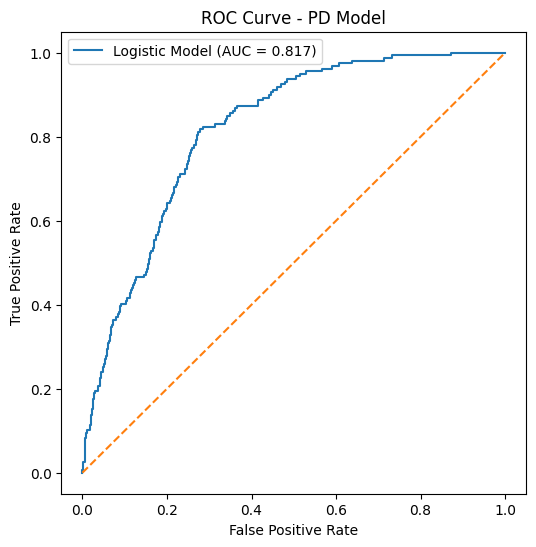

In [19]:
# Creating a ROC curve
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label="Logistic Model (AUC = 0.817)")
plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - PD Model")
plt.legend()

plt.show()

The ROC curve evaluates the model across all classification thresholds by plotting the True Positive Rate against the False Positive Rate. The AUC summarizes the model’s overall ability to discriminate between defaulting and non-defaulting loans. In our case, the AUC of 0.817 indicates strong discriminatory power.

# Risk Ranking (Decile Analysis)
To evaluate how well the model ranks loans by risk, predicted probabilities were divided into 10 equal groups (deciles).

Loans in higher deciles represent higher predicted risk.

If the model is working properly, the observed default rate should increase across deciles.

In [10]:
# Segmenting probabilities by deciles
import numpy as np

df_model = X_test.copy()
df_model["actual_default"] = y_test.values
df_model["pd"] = y_pred_proba

df_model["decile"] = pd.qcut(df_model["pd"], 10, labels=False)

**Sorting loans according to predicted PD(Probability of Default) then splitting them into 10 equal risk groups** 

In [12]:
# Computing summary statistics for each decile and creating an evaluation table
decile_summary = df_model.groupby("decile").agg(
    avg_pd=("pd", "mean"),
    default_rate=("actual_default", "mean"),
    count=("actual_default", "count")
).sort_index()

decile_summary

,avg_pd,default_rate,count
decile,,,
0,0.001035,0.000000,712
1,0.002475,0.001404,712
2,0.004147,0.002813,711
3,0.006307,0.002809,712
4,0.009255,0.007022,712
5,0.013100,0.014065,711
6,0.018646,0.011236,712
7,0.027905,0.046414,711
8,0.044865,0.047753,712


### Top Decile i.e. decile 9
avg_pd = 10.0%

actual default = 8.9%
### Bottom Decile i.e. decile 0
avg_pd = 0.1%

actual default = 0%

This means that the model correctly placed most defaults in the high-risk buckets and is separating safe vs risky loans hence the high AUC.

Financial institutions want to know:
- Which risk bucket loans fall into
- How default rate changes across buckets

So this model can help make decisions such as:

Decile	Default Rate
- 0-4	safe
- 5-7	medium risk
- 8-9	high risk

They can then:
- Adjust interest rates
- Approve fewer risky loans
- Allocate capital

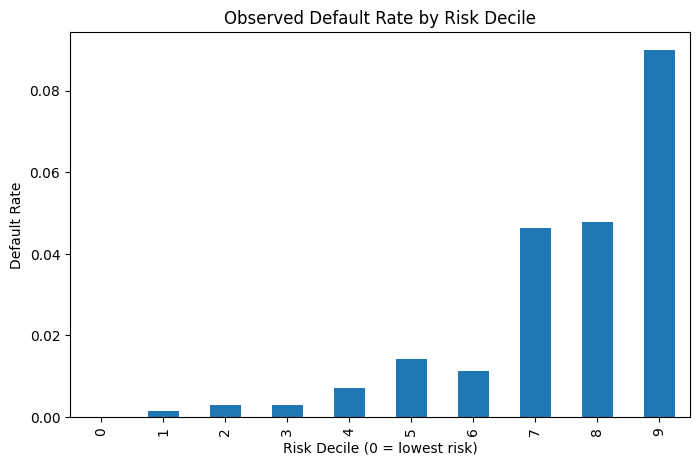

In [20]:
# Plotting default rate by risk decile
decile_summary.reset_index().plot(
    x="decile",
    y="default_rate",
    kind="bar",
    figsize=(8,5),
    legend=False
)

plt.title("Observed Default Rate by Risk Decile")
plt.xlabel("Risk Decile (0 = lowest risk)")
plt.ylabel("Default Rate")

plt.show()

# Risk Drivers
Logistic regression coefficients provide insight into the drivers of default risk.

Positive coefficients increase default probability, while negative coefficients decrease it.

Key findings from the model include:

- Higher interest rates are associated with higher default risk

- Higher LTV is associated with increased risk

- Higher DTI is associated with increased risk

- Higher credit scores are associated with lower risk

- Loans with multiple borrowers tend to have lower risk.

In [14]:
# Showing which borrower characteristics drive default
coef_table = pd.DataFrame({
    "feature": X_encoded.columns,
    "coefficient": model.coef_[0]
}).sort_values("coefficient", ascending=False)
coef_table["coefficient"] = coef_table["coefficient"].round(4)

coef_table

,feature,coefficient
1,original_interest_rate,0.8847
9,occupancy_status_P,0.3405
13,property_type_PU,0.1515
12,property_type_MH,0.0994
4,dti,0.0388
3,original_ltv,0.0284
2,original_loan_term,0.0010
0,original_upb,0.0000
11,property_type_CP,-0.0096
5,credit_score,-0.0143


In [15]:
# Risk segmentation by credit scores
df_model["credit_score"] = X_test["credit_score"]

pd.cut(df_model["credit_score"],
       bins=[500,620,680,740,800,850]).value_counts()

credit_score
(740, 800]    3584
(680, 740]    1783
(800, 850]    1125
(620, 680]     614
(500, 620]      11
Name: count, dtype: int64

# Portfolio Insights
From the analysis:

Portfolio default rate = **2.24%**

Highest risk decile default rate = **8.9%**

Lowest risk decile default rate = **0%**

This confirms that the model effectively ranks loans by credit risk.

Such models can be used by lenders to:

- Identify higher-risk borrowers

- Adjust lending policies

- Support portfolio risk monitoring.

# Conclusion
This project demonstrates an end-to-end credit risk modeling workflow:

- Transforming raw loan performance data

- Defining default

- Building a probability of default model

- Evaluating model discrimination

- Interpreting risk drivers.

# Author
## Naomi Wanjiru